In [1]:

import os, random, sys
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
)

# ----------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------
def set_seed(s=42):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# ----------------------------------------------------------------------
# Paths / dataset info
# ----------------------------------------------------------------------
DEVICE    = torch.device("cpu")    # δουλεύουμε μόνο σε CPU
DATA_DIR  = os.path.join("..", "data")
IMAGES_DIR = os.path.join(DATA_DIR, "HAM_10000_images")
META_CSV   = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
SPLIT_CSV  = "ham10000_split_v2.csv"   # αυτό που είχαμε φτιάξει πριν

assert os.path.exists(META_CSV),  "Λείπει το metadata CSV"
assert os.path.exists(SPLIT_CSV), "Λείπει το split CSV"
assert os.path.isdir(IMAGES_DIR), "Λείπει ο φάκελος εικόνων"

CLASS_NAMES = ['akiec','bcc','bkl','df','mel','nv','vasc']
class_to_idx = {c:i for i,c in enumerate(CLASS_NAMES)}
idx_to_class = {i:c for c,i in class_to_idx.items()} 


In [2]:
# ----------------------------------------------------------------------
# Φόρτωση metadata και merge με το split
# ----------------------------------------------------------------------
meta = pd.read_csv(META_CSV)
split = pd.read_csv(SPLIT_CSV)

# filename + πλήρης διαδρομή
meta['filename'] = meta['image_id'] + ".jpg"
meta['filepath'] = meta['filename'].apply(lambda x: os.path.join(IMAGES_DIR, x))

# merge με το split για να έχουμε και τη στήλη 'split'
df = meta.merge(split[['image_id','lesion_id','dx','split']],
                on=['image_id','lesion_id','dx'],
                how='inner')

df_train = df[df["split"]=="train"].reset_index(drop=True)
df_val   = df[df["split"]=="val"  ].reset_index(drop=True)
df_test  = df[df["split"]=="test" ].reset_index(drop=True)

print(len(df_train), len(df_val), len(df_test))
df_train.head()


8001 1009 1005


,lesion_id,image_id,dx,dx_type,age,sex,localization,filename,filepath,split
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,ISIC_0027419.jpg,..\data\HAM_10000_images\ISIC_0027419.jpg,train
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,ISIC_0025030.jpg,..\data\HAM_10000_images\ISIC_0025030.jpg,train
2,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,ISIC_0031633.jpg,..\data\HAM_10000_images\ISIC_0031633.jpg,train
3,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,ISIC_0027850.jpg,..\data\HAM_10000_images\ISIC_0027850.jpg,train
4,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,ISIC_0029176.jpg,..\data\HAM_10000_images\ISIC_0029176.jpg,train


In [3]:
# ----------------------------------------------------------------------
# Transforms (ίδια ImageNet normalization με το TL μοντέλο)
# ----------------------------------------------------------------------
IMG_SIZE   = 224
IMNET_MEAN = [0.485, 0.456, 0.406]
IMNET_STD  = [0.229, 0.224, 0.225]

eval_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])

class SkinDataset(Dataset):
    def __init__(self, df, transform=None, class_to_idx=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[row["dx"]]
        return img, label, row["image_id"]

train_ds = SkinDataset(df_train, transform=eval_tfms, class_to_idx=class_to_idx)
val_ds   = SkinDataset(df_val,   transform=eval_tfms, class_to_idx=class_to_idx)
test_ds  = SkinDataset(df_test,  transform=eval_tfms, class_to_idx=class_to_idx)

BATCH = 64  # batch για feature extraction (μόνο forward, άρα αντέχει λίγο μεγαλύτερο)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=False, num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

len(train_dl), len(val_dl), len(test_dl)


(126, 16, 16)

In [5]:
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

CKPT = "best_mbv3_tl.pt"

# 1. Φτιάξε το ΜΟΝΤΕΛΟ όπως στο training
try:
    weights = MobileNet_V3_Small_Weights.DEFAULT
    base = mobilenet_v3_small(weights=weights)
except:
    base = mobilenet_v3_small(pretrained=True)

# 2. Αντικατάσταση classifier -> 7 classes
in_features = base.classifier[-1].in_features
base.classifier[-1] = nn.Linear(in_features, len(CLASS_NAMES))

# 3. Φόρτωση weights από το TL checkpoint
state = torch.load(CKPT, map_location=DEVICE)
missing, unexpected = base.load_state_dict(state, strict=False)

print("Missing:", missing)
print("Unexpected:", unexpected)

base.eval()


Missing: []
Unexpected: []


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [6]:
feature_extractor = nn.Sequential(
    base.features,
    base.avgpool,
    nn.Flatten()
).to(DEVICE)

feature_extractor.eval()


Sequential(
  (0): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(

In [7]:
import torch
import numpy as np

def extract_features(dataloader, model, device=DEVICE):
    model.eval()
    feats = []
    labels = []

    with torch.no_grad():
        for xb, yb, _ in dataloader:
            xb = xb.to(device)
            f = model(xb)              # CNN → feature vector
            feats.append(f.cpu().numpy())
            labels.append(yb.numpy())

    feats = np.concatenate(feats, axis=0)
    labels = np.concatenate(labels, axis=0)
    return feats, labels


In [8]:


train_feats, train_labels = extract_features(train_dl, feature_extractor)
val_feats,   val_labels   = extract_features(val_dl,   feature_extractor)
test_feats,  test_labels  = extract_features(test_dl,  feature_extractor)

train_feats.shape, val_feats.shape, test_feats.shape


((8001, 576), (1009, 576), (1005, 576))

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score

svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')

svm.fit(train_feats, train_labels)
pred = svm.predict(test_feats)

print("SVM Balanced Acc:", balanced_accuracy_score(test_labels, pred))
print("SVM Macro F1:", f1_score(test_labels, pred, average="macro"))
print(classification_report(test_labels, pred, target_names=CLASS_NAMES))


SVM Balanced Acc: 0.6881144829198076
SVM Macro F1: 0.6955979576454066
              precision    recall  f1-score   support

       akiec       0.42      0.62      0.50        24
         bcc       0.73      0.70      0.71        53
         bkl       0.70      0.72      0.71       124
          df       1.00      0.50      0.67         8
         mel       0.57      0.56      0.56       114
          nv       0.93      0.91      0.92       667
        vasc       0.80      0.80      0.80        15

    accuracy                           0.83      1005
   macro avg       0.73      0.69      0.70      1005
weighted avg       0.83      0.83      0.83      1005



In [10]:
import matplotlib.pyplot as plt
import numpy as np

def show_svm_prediction(image_id, df=df_test):
    # 1. Βρες τη γραμμή για το συγκεκριμένο image_id
    row = df[df["image_id"] == image_id].iloc[0]
    path = row["filepath"]
    true_lbl = row["dx"]

    # 2. Φόρτωσε την εικόνα (όπως είναι) για να τη δείξουμε
    img = Image.open(path).convert("RGB")

    # 3. Ετοίμασε το tensor για το CNN (ίδιο eval_tfms με test set)
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)   # shape [1, 3, 224, 224]

    # 4. Πέρασε την εικόνα από το feature extractor (MobileNetV3 χωρίς classifier)
    feature_extractor.eval()
    with torch.no_grad():
        z = feature_extractor(x)                 # shape [1, d]

    # 5. Μετατροπή σε NumPy για χρήση από το SVM
    z_np = z.cpu().numpy()                       # shape [1, d]

    # 6. Πρόβλεψη κλάσης από το SVM
    pred_idx = svm.predict(z_np)[0]             # ακέραιος 0–6
    pred_name = CLASS_NAMES[pred_idx]

    # 7. Πάρε τα "scores" όλων των κλάσεων και κάνε softmax για pseudo-probs
    scores = svm.decision_function(z_np)[0]     # shape [7]
    exp_scores = np.exp(scores - scores.max())  # αριθμητικά σταθερό softmax
    probs = exp_scores / exp_scores.sum()
    pred_conf = probs[pred_idx]

    # 8. Plot: εικόνα + barplot πιθανοτήτων
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image: {image_id}\nTrue: {true_lbl}")

    plt.subplot(1, 2, 2)
    plt.bar(range(len(CLASS_NAMES)), probs)
    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
    plt.ylabel("SVM pseudo-probbility")
    plt.title(f"Pred: {pred_name} ({pred_conf*100:.1f}%)")

    plt.tight_layout()
    plt.show()

    # 9. Εκτύπωσε και κειμενικά τα βασικά
    print(f"True label : {true_lbl}")
    print(f"Pred label : {pred_name}")
    print(f"Pseudo-confidence: {pred_conf*100:.2f}%")
    print("Probs per class:")
    for c, p in zip(CLASS_NAMES, probs):
        print(f"  {c:5s}: {p*100:5.2f}%")


In [11]:
random_id = df_test.sample(1)["image_id"].iloc[0]
random_id


'ISIC_0028865'

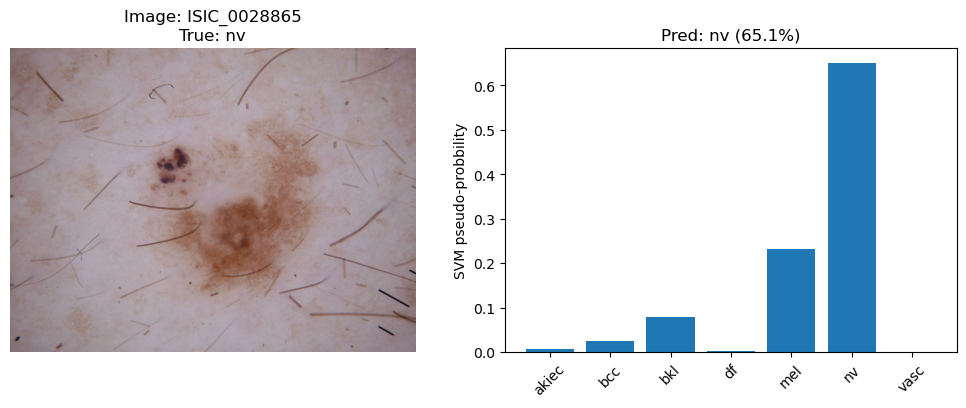

True label : nv
Pred label : nv
Pseudo-confidence: 65.08%
Probs per class:
  akiec:  0.67%
  bcc  :  2.55%
  bkl  :  8.03%
  df   :  0.24%
  mel  : 23.35%
  nv   : 65.08%
  vasc :  0.09%


In [12]:
show_svm_prediction(random_id)


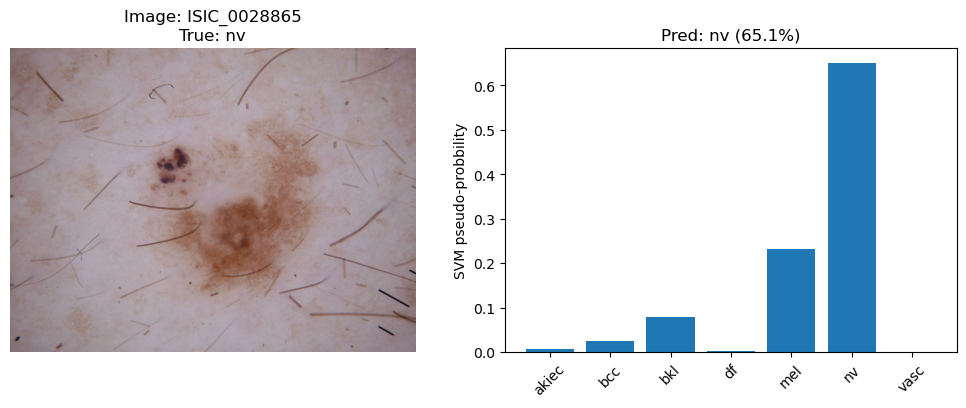

True label : nv
Pred label : nv
Pseudo-confidence: 65.08%
Probs per class:
  akiec:  0.67%
  bcc  :  2.55%
  bkl  :  8.03%
  df   :  0.24%
  mel  : 23.35%
  nv   : 65.08%
  vasc :  0.09%


In [13]:
show_svm_prediction(random_id)

In [14]:
random_id = df_test.sample(1)["image_id"].iloc[0]
random_id

'ISIC_0028232'

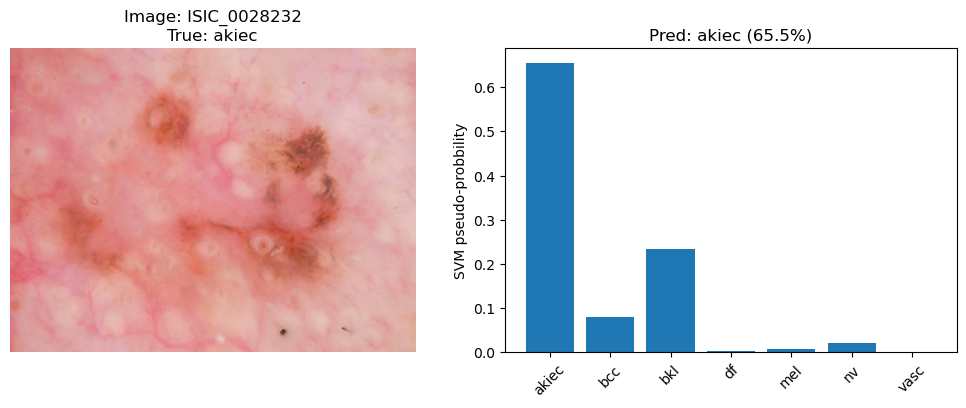

True label : akiec
Pred label : akiec
Pseudo-confidence: 65.49%
Probs per class:
  akiec: 65.49%
  bcc  :  7.97%
  bkl  : 23.42%
  df   :  0.25%
  mel  :  0.71%
  nv   :  2.07%
  vasc :  0.09%


In [15]:
show_svm_prediction(random_id)

In [16]:
# === Βασικές παράμετροι εικόνας ===
IMG = 224
IMNET_MEAN = [0.485, 0.456, 0.406]
IMNET_STD  = [0.229, 0.224, 0.225]

# === Eval transforms ===
import torchvision.transforms as transforms

eval_tfms = transforms.Compose([
    transforms.Resize(IMG+32),
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])


In [17]:
IMG

224

In [18]:
import torchvision.transforms as T

tta_transforms = [
    # Original eval transform
    eval_tfms,

    # Horizontal flip
    T.Compose([
        T.Resize(IMG+32),
        T.CenterCrop(IMG),
        T.RandomHorizontalFlip(p=1.0),
        T.ToTensor(),
        T.Normalize(IMNET_MEAN, IMNET_STD),
    ]),

    # Vertical flip
    T.Compose([
        T.Resize(IMG+32),
        T.CenterCrop(IMG),
        T.RandomVerticalFlip(p=1.0),
        T.ToTensor(),
        T.Normalize(IMNET_MEAN, IMNET_STD),
    ]),

    # Small rotation
    T.Compose([
        T.Resize(IMG+32),
        T.CenterCrop(IMG),
        T.RandomRotation(15),
        T.ToTensor(),
        T.Normalize(IMNET_MEAN, IMNET_STD),
    ]),
]


In [19]:
import torch
import numpy as np

def extract_tta_features(image_path, feature_extractor, tta_transforms, device="cpu"):
    """
    Επιστρέφει τον μέσο όρο των TTA features για μία εικόνα.
    """
    img = Image.open(image_path).convert("RGB")

    feats = []

    for tfm in tta_transforms:
        x = tfm(img).unsqueeze(0).to(device)
        with torch.no_grad():
            f = feature_extractor(x).cpu().numpy().flatten()
        feats.append(f)

    # μέσος όρος όλων των TTA feature vectors
    return np.mean(feats, axis=0)


In [20]:
tta_test_feats = []
tta_test_labels = []

for idx, row in df_test.iterrows():
    path = row["filepath"]
    label = class_to_idx[row["dx"]]

    feats = extract_tta_features(path, feature_extractor, tta_transforms, device=DEVICE)
    
    tta_test_feats.append(feats)
    tta_test_labels.append(label)

tta_test_feats = np.array(tta_test_feats)
tta_test_labels = np.array(tta_test_labels)

print("TTA Test Features Shape:", tta_test_feats.shape)


TTA Test Features Shape: (1005, 576)


In [21]:


tta_pred = svm.predict(tta_test_feats)

from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report

print("TTA Hybrid Balanced Acc.:", balanced_accuracy_score(tta_test_labels, tta_pred))
print("TTA Hybrid Macro F1:", f1_score(tta_test_labels, tta_pred, average="macro"))
print(classification_report(tta_test_labels, tta_pred, target_names=CLASS_NAMES))


TTA Hybrid Balanced Acc.: 0.7000761243653407
TTA Hybrid Macro F1: 0.7147260808117418
              precision    recall  f1-score   support

       akiec       0.47      0.62      0.54        24
         bcc       0.79      0.77      0.78        53
         bkl       0.72      0.77      0.74       124
          df       1.00      0.50      0.67         8
         mel       0.61      0.58      0.59       114
          nv       0.93      0.92      0.93       667
        vasc       0.79      0.73      0.76        15

    accuracy                           0.84      1005
   macro avg       0.76      0.70      0.71      1005
weighted avg       0.85      0.84      0.84      1005



In [22]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

feature_extractor.eval()

with torch.no_grad():
    for imgs, labels, _ in test_dl:

        imgs = imgs.to(DEVICE)

        # CNN feature extraction
        feats = feature_extractor(imgs)
        feats = feats.cpu().numpy()

        # SVM prediction
        preds = svm.predict(feats)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)



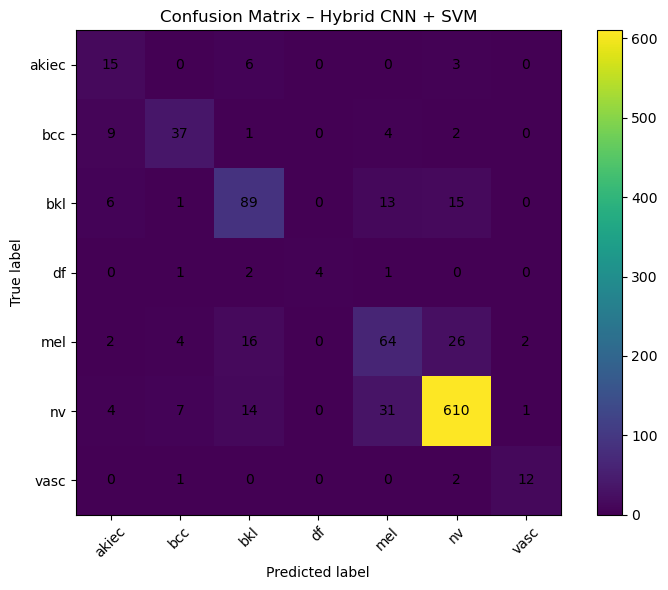

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
plt.yticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Hybrid CNN + SVM")
plt.tight_layout()
plt.show()



In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show_hybrid_prediction_random(df, feature_extractor, svm, eval_tfms, class_names, device="cpu", seed=None):
    if seed is not None:
        np.random.seed(seed)

    row = df.sample(1).iloc[0]
    path = row["filepath"]
    true_lbl = row["dx"]

    # load image
    img = Image.open(path).convert("RGB")

    # CNN -> feature vector (1,d)
    x = eval_tfms(img).unsqueeze(0).to(device)
    feature_extractor.eval()
    with torch.no_grad():
        z = feature_extractor(x).cpu().numpy()  # shape [1,d]

    # SVM prediction
    pred_idx = int(svm.predict(z)[0])
    pred_name = class_names[pred_idx]

    # pseudo-probabilities via stable softmax on decision scores
    scores = svm.decision_function(z)[0]               # shape [K]
    exp_scores = np.exp(scores - scores.max())
    probs = exp_scores / exp_scores.sum()

    # plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_lbl}")

    plt.subplot(1,2,2)
    plt.bar(range(len(class_names)), probs)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.ylim(0,1)
    plt.title(f"Hybrid Pred: {pred_name} ({probs[pred_idx]*100:.1f}%)")
    plt.tight_layout()
    plt.show()

    print(f"[HYBRID] True: {true_lbl} | Pred: {pred_name} | Conf: {probs[pred_idx]:.2%} | Correct: {pred_name==true_lbl}")

# Χρήση (π.χ. στο test)



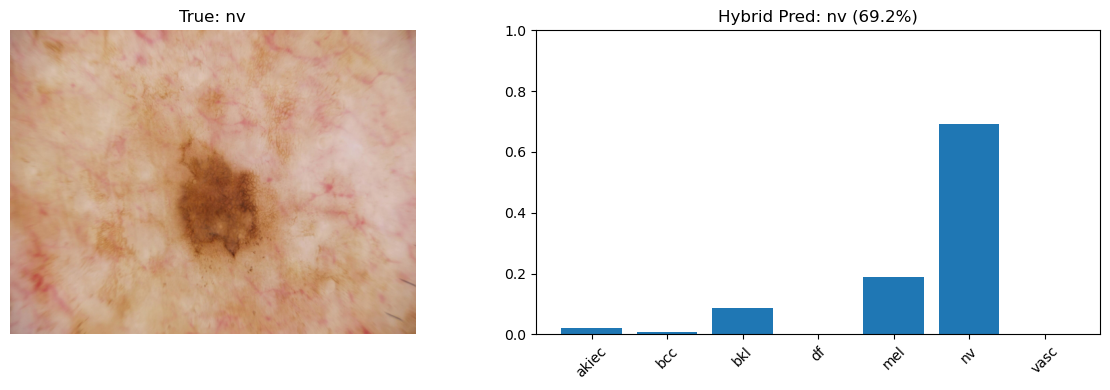

[HYBRID] True: nv | Pred: nv | Conf: 69.21% | Correct: True


In [25]:
show_hybrid_prediction_random(df_test, feature_extractor, svm, eval_tfms, CLASS_NAMES, DEVICE, seed=42)

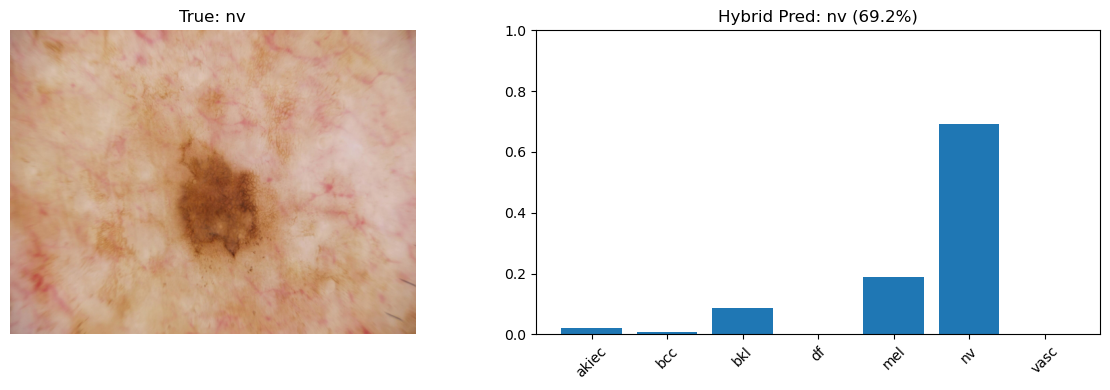

[HYBRID] True: nv | Pred: nv | Conf: 69.21% | Correct: True


In [26]:
show_hybrid_prediction_random(df_test, feature_extractor, svm, eval_tfms, CLASS_NAMES, DEVICE, seed=42)

In [27]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca_features(feats, labels, class_names):
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(feats)

    plt.figure(figsize=(7,6))
    plt.scatter(Z[:,0], Z[:,1], c=labels, s=8)
    plt.title("PCA of CNN Feature Vectors (Hybrid setup)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    cbar = plt.colorbar()
    cbar.set_ticks(range(len(class_names)))
    cbar.set_ticklabels(class_names)
    plt.tight_layout()
    plt.show()

# Χρήση:
# plot_pca_features(test_feats, test_labels, CLASS_NAMES)


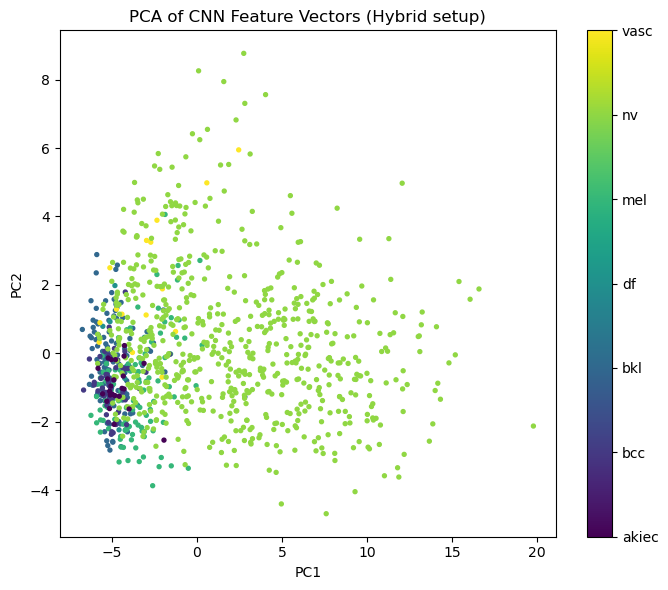

In [28]:
plot_pca_features(test_feats, test_labels, CLASS_NAMES)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

def show_hybrid_tta_comparison(
    df,
    feature_extractor,
    svm,
    eval_tfms,
    tta_transforms,
    class_names,
    device="cpu",
    seed=None
):
    if seed is not None:
        np.random.seed(seed)

    # τυχαία εικόνα
    row = df.sample(1).iloc[0]
    path = row["filepath"]
    true_lbl = row["dx"]

    img = Image.open(path).convert("RGB")

    # ---------- ΧΩΡΙΣ TTA ----------
    x = eval_tfms(img).unsqueeze(0).to(device)
    feature_extractor.eval()
    with torch.no_grad():
        z = feature_extractor(x).cpu().numpy()

    scores = svm.decision_function(z)[0]
    exp_scores = np.exp(scores - scores.max())
    probs_no_tta = exp_scores / exp_scores.sum()

    pred_no_tta = class_names[np.argmax(probs_no_tta)]

    # ---------- ΜΕ TTA ----------
    feats = []
    for tfm in tta_transforms:
        x_tta = tfm(img).unsqueeze(0).to(device)
        with torch.no_grad():
            f = feature_extractor(x_tta).cpu().numpy().flatten()
        feats.append(f)

    z_tta = np.mean(feats, axis=0, keepdims=True)
    scores_tta = svm.decision_function(z_tta)[0]
    exp_scores_tta = np.exp(scores_tta - scores_tta.max())
    probs_tta = exp_scores_tta / exp_scores_tta.sum()

    pred_tta = class_names[np.argmax(probs_tta)]

    # ---------- PLOT ----------
    plt.figure(figsize=(14,4))

    # εικόνα
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True label: {true_lbl}")

    # χωρίς TTA
    plt.subplot(1,3,2)
    plt.bar(range(len(class_names)), probs_no_tta)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.ylim(0,1)
    plt.title(f"Hybrid (no TTA)\nPred: {pred_no_tta} ({probs_no_tta.max()*100:.1f}%)")

    # με TTA
    plt.subplot(1,3,3)
    plt.bar(range(len(class_names)), probs_tta)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.ylim(0,1)
    plt.title(f"Hybrid + TTA\nPred: {pred_tta} ({probs_tta.max()*100:.1f}%)")

    plt.tight_layout()
    plt.show()

    print(
        f"[HYBRID] True: {true_lbl} | "
        f"No TTA: {pred_no_tta} | "
        f"TTA: {pred_tta}"
    )


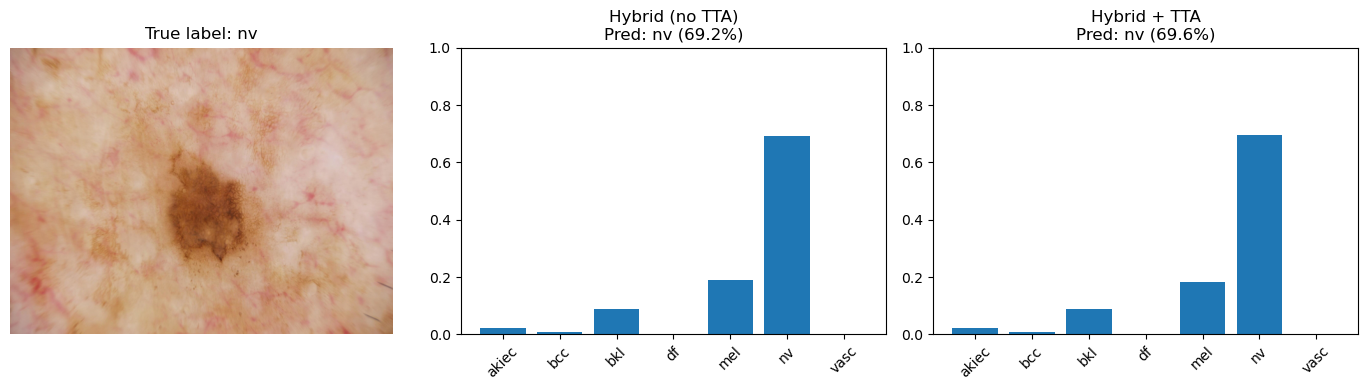

[HYBRID] True: nv | No TTA: nv | TTA: nv


In [25]:
show_hybrid_tta_comparison(
    df_test,
    feature_extractor,
    svm,
    eval_tfms,
    tta_transforms,
    CLASS_NAMES,
    device=DEVICE,
    seed=42
)


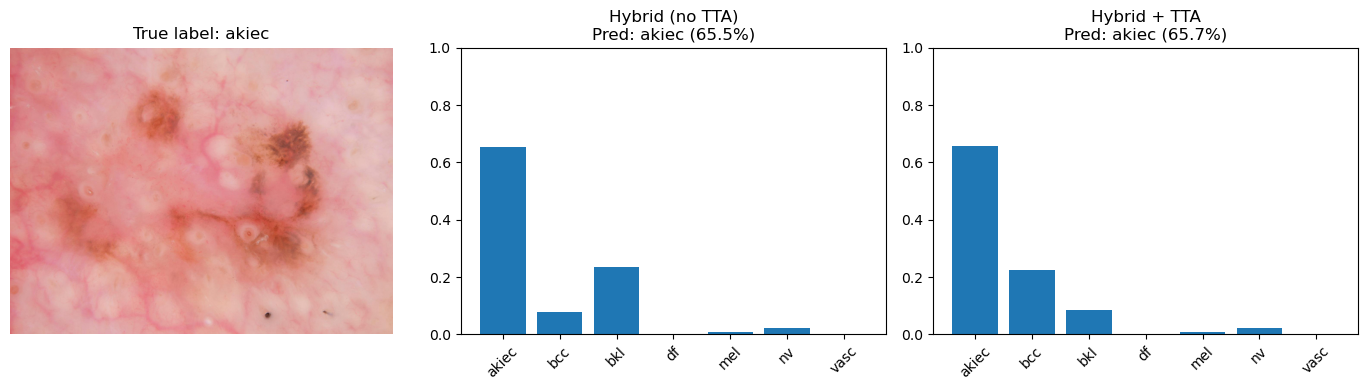

[HYBRID] True: akiec | No TTA: akiec | TTA: akiec


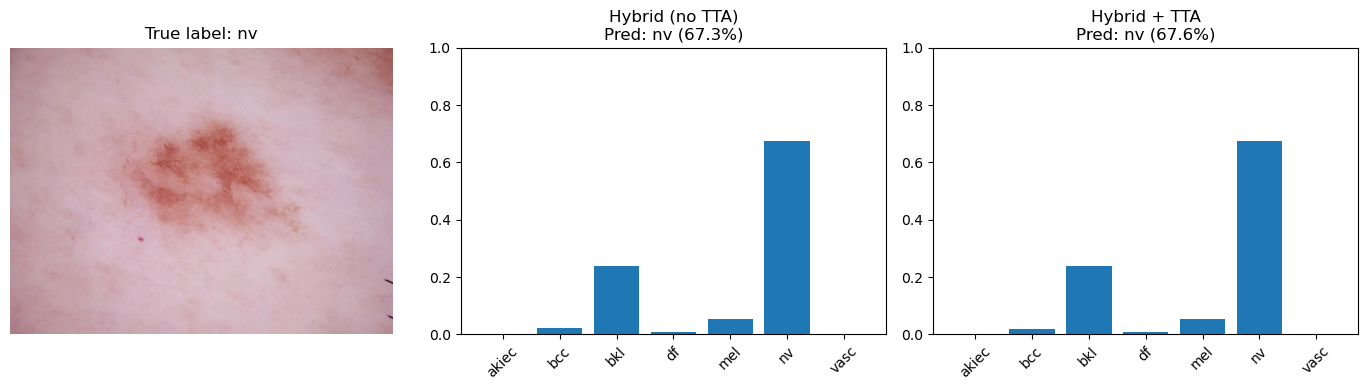

[HYBRID] True: nv | No TTA: nv | TTA: nv


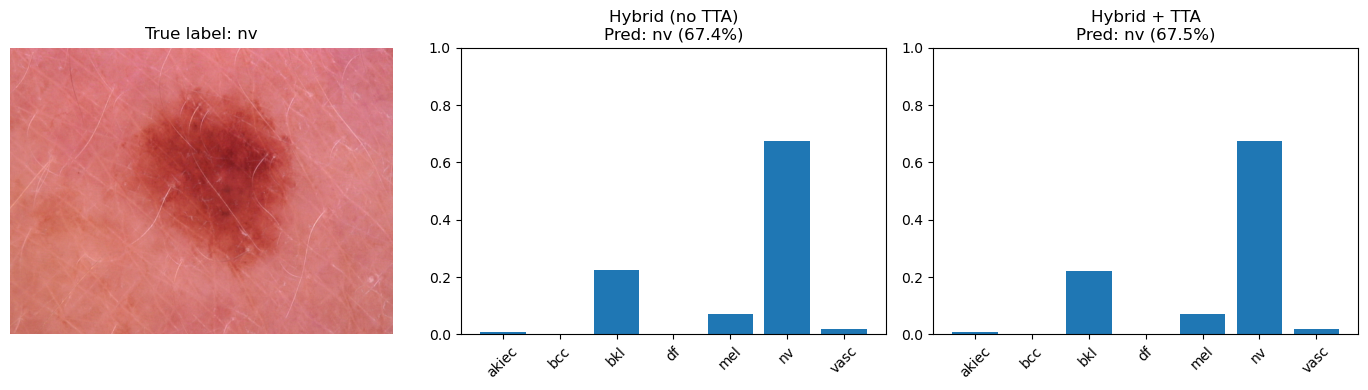

[HYBRID] True: nv | No TTA: nv | TTA: nv


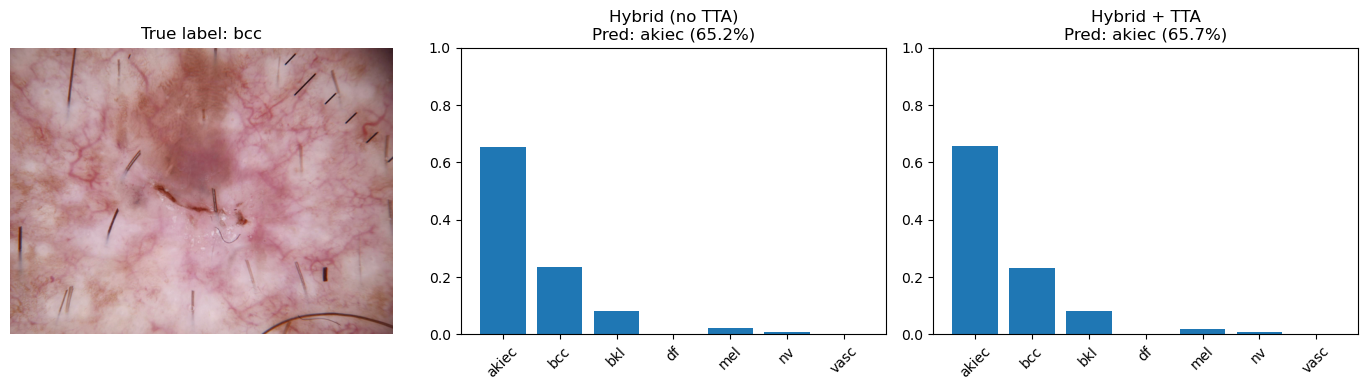

[HYBRID] True: bcc | No TTA: akiec | TTA: akiec


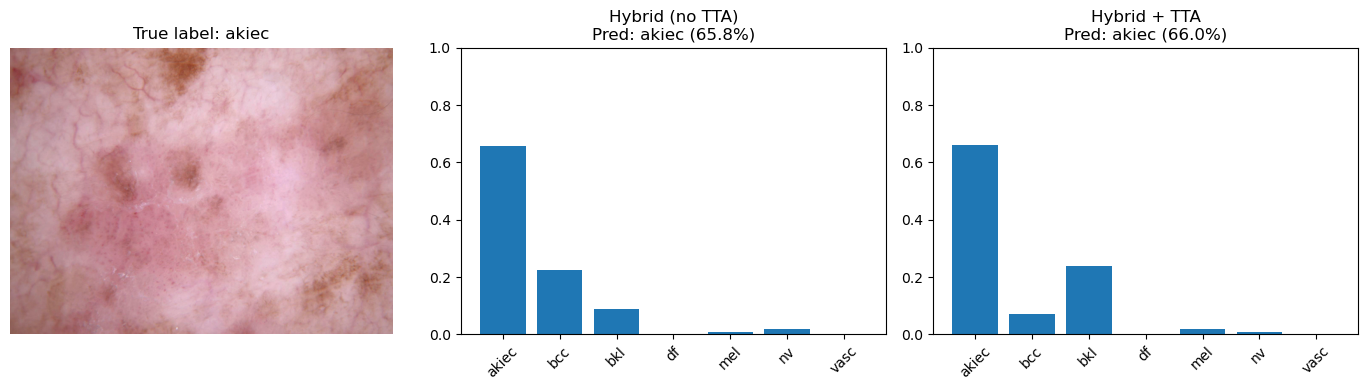

[HYBRID] True: akiec | No TTA: akiec | TTA: akiec


In [30]:
for i in range(5):
    show_hybrid_tta_comparison(
        df_test,
        feature_extractor,
        svm,
        eval_tfms,
        tta_transforms,
        CLASS_NAMES,
        device=DEVICE
    )
